# Hidden Objects Dataset — Visualization

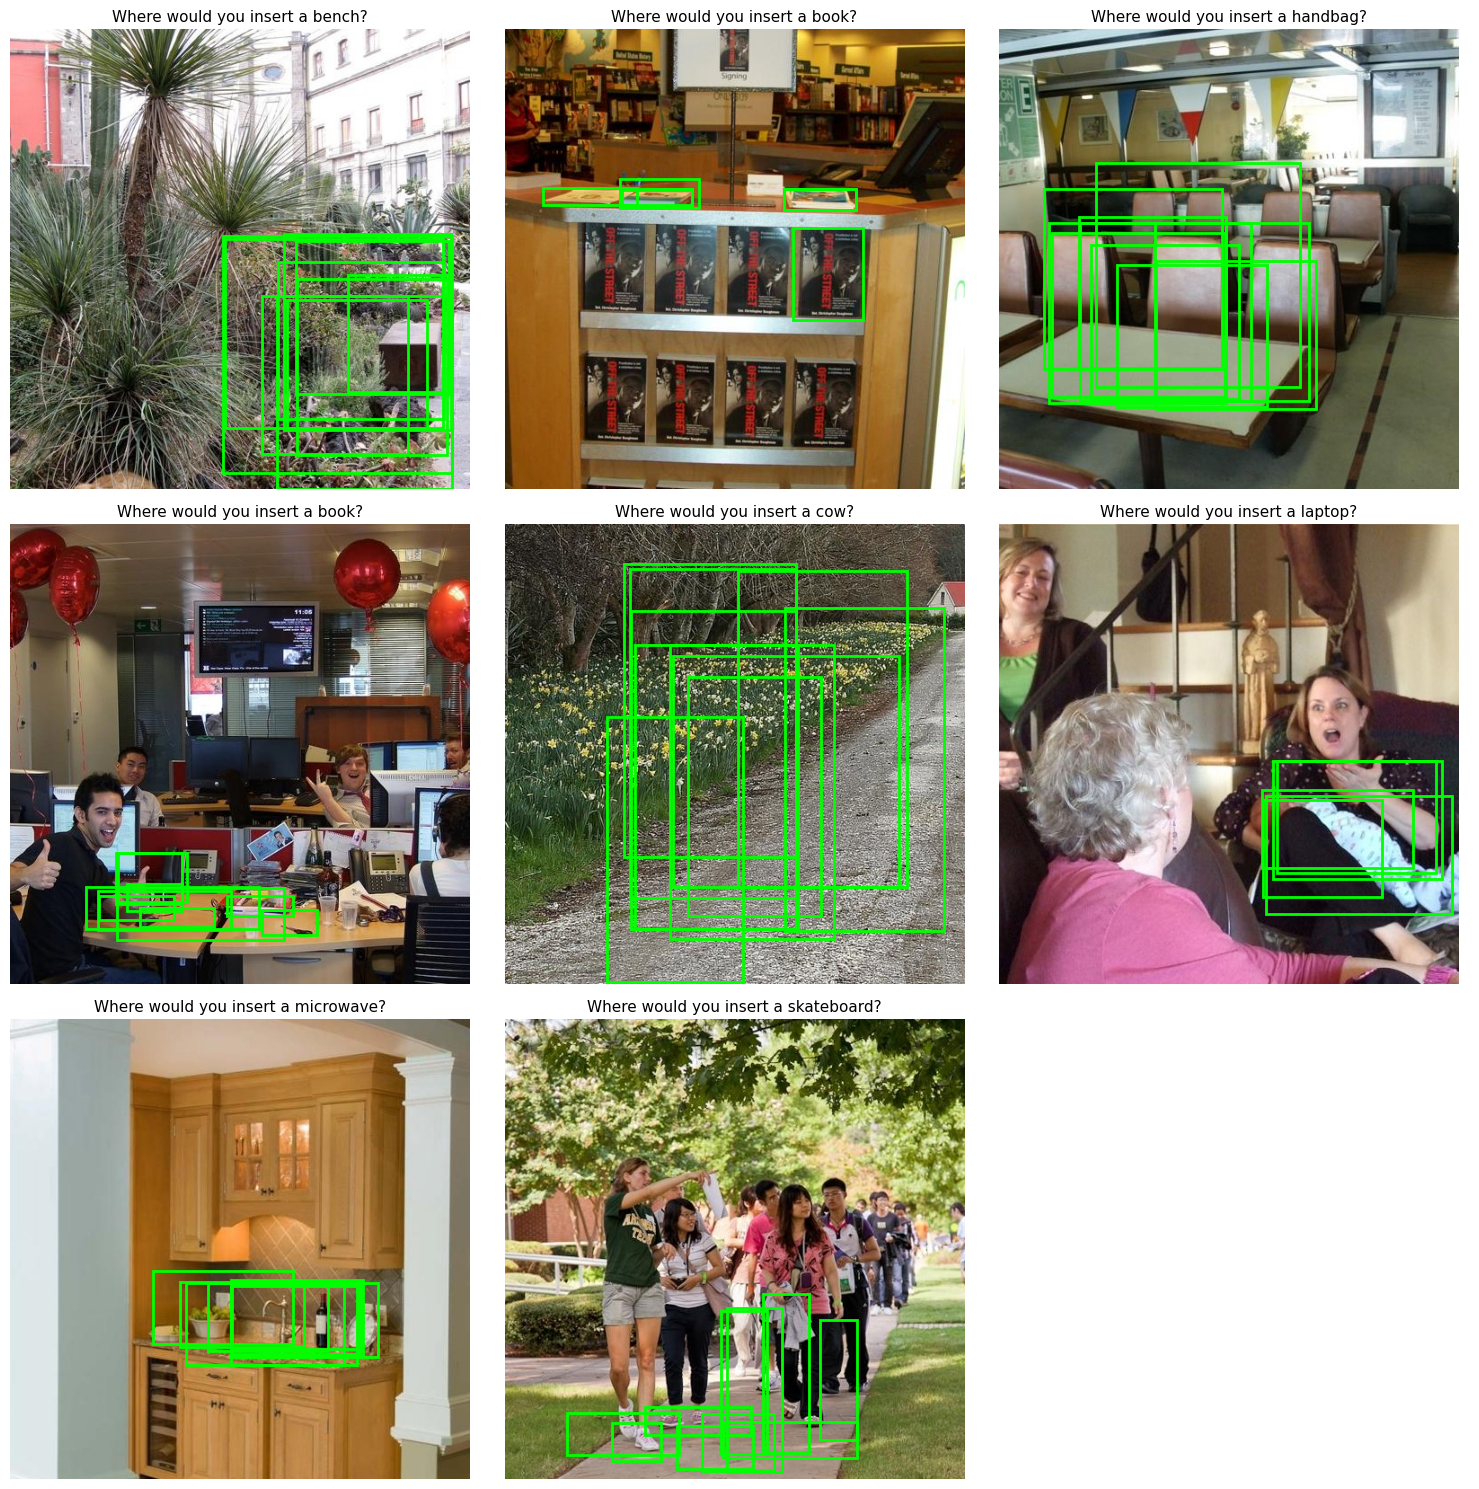

In [ ]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "matplotlib", "Pillow"])

import json, os
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

IMG_SIZE = 512
DEMO_DIR = "demo_images"
JSONL_PATH = "ho_irany_train_rel_top1.jsonl"

DEMO = [
    ("data_large_standard/c/courtyard/00004915.jpg",   "bench"),
    ("data_large_standard/b/bookstore/00000011.jpg",   "book"),
    ("data_large_standard/c/coffee_shop/00001155.jpg", "handbag"),
    ("data_large_standard/o/office/00004013.jpg",      "book"),
    ("data_large_standard/f/farm/00003647.jpg",        "cow"),
    ("data_large_standard/d/dorm_room/00004560.jpg",   "laptop"),
    ("data_large_standard/k/kitchen/00003654.jpg",     "microwave"),
    ("data_large_standard/c/campus/00004181.jpg",      "skateboard"),
]
demo_keys = {(bg, cls) for bg, cls in DEMO}

entries = defaultdict(list)
with open(JSONL_PATH) as f:
    for line in f:
        r = json.loads(line)
        if (r["bg_path"], r["fg_class"]) in demo_keys and r["label"] == 1:
            entries[(r["bg_path"], r["fg_class"])].append(r)

def center_crop_512(img):
    w, h = img.size
    left, top = (w - IMG_SIZE) // 2, (h - IMG_SIZE) // 2
    return img.crop((left, top, left + IMG_SIZE, top + IMG_SIZE))

# Grid layout: 3 columns
ncols = 3
nrows = (len(DEMO) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))
axes = axes.flatten()

for idx, (bg_path, fg_class) in enumerate(DEMO):
    ax = axes[idx]
    rows = entries.get((bg_path, fg_class), [])

    img = center_crop_512(Image.open(os.path.join(DEMO_DIR, bg_path)).convert("RGB"))
    top_rows = sorted(rows, key=lambda r: -r["image_reward_score"])[:10]

    ax.imshow(img)
    for r in top_rows:
        x, y, w, h = r["bbox"]
        rect = patches.Rectangle(
            (x * IMG_SIZE, y * IMG_SIZE), w * IMG_SIZE, h * IMG_SIZE,
            linewidth=2, edgecolor="lime", facecolor="none",
        )
        ax.add_patch(rect)

    ax.set_title(f"Where would you insert a {fg_class}?", fontsize=11)
    ax.axis("off")

for idx in range(len(DEMO), len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
plt.show()